In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor
import torch

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

processor = Qwen2_5_VLProcessor.from_pretrained(model_id)
print("Successfully loaded the model")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


Successfully loaded the model


In [2]:
adapter_path = "qwen2-7b-instruct-trl-sft-NEW"
model.load_adapter(adapter_path)

In [5]:
from PIL import Image
import json

system_message = """You are a Vision Language Model specialized in detecting clues of fire, smoke and surrounding context then classify them as no fire, dangerous fire or controlled fire.
Your task is to analyze the provided image and respond to queries with concise answers, usually a json format of a caption and a label.
Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.
Based on your summary, classify the fire situation: no fire(e.g., fire alarm, fire distinguisher,..), controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)
Focus on delivering accurate, succinct caption and precise label based on the visual information. Add a brief explanation for your choice of label in the caption if necessary."""

user_query = """Summarize this situation in the image, look for signs of fire and smoke and classify whether the situation is: \n
- **No fire**: The image may contain symbols, representations, or objects related to fire, but no actual fire or smoke is present. This includes things like warning signs, fire safety equipment (extinguishers, alarms), digital or printed representations of fire (e.g., a laptop screen showing fire, a drawing or painting), or thematic decorations.\n
- **Controlled fire**: There is a visible flame or heat source, but it is clearly contained, expected, and managed by people or objects in its environment. This includes fireplaces, campfires, cooking appliances, candles, lighters, or matchsticks. There should be no signs of danger, spread, panic, or damage in the surroundings.\n
- **Dangerous (uncontrolled) fire**: The fire appears out of control or harmful to the environment or people. Signs include flames spreading to flammable materials (e.g., curtains, furniture, bedding), thick smoke near the ceiling, charring, visible structural damage, or people reacting with fear or urgency. The context suggests potential or ongoing property damage or bodily harm.\n
Add a brief explanation for your choice of label in the caption if necessary.\n
Respond only this json format:\n
{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }
"""

def format_data(sample):
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_message}],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"file://{sample['image_path']}",
                },
                {
                    "type": "text",
                    "text": user_query,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": f"""```json\n{json.dumps({"caption": sample["caption"], "label": sample["label"]}, ensure_ascii=False)}\n```"""
                }
            ],
        },
    ]


In [6]:
from qwen_vl_utils import process_vision_info
import pandas as pd

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Apply full chat template including system message
    text_input = processor.apply_chat_template(
        sample, tokenize=False, add_generation_prompt=True
    )

    # Process the visual input
    image_inputs, _ = process_vision_info(sample)

    # Prepare model inputs
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)

    # Generate response
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim input tokens from generated output
    trimmed_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)]

    # Decode to string
    output_text = processor.batch_decode(
        trimmed_generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    return output_text[0]

train_df = pd.read_csv("train_labels.csv")
train_dataset = [format_data(sample) for sample in train_df.to_dict('records')]

output = generate_text_from_sample(model, processor, train_dataset[0])
output

'```json\n{"caption": "The image depicts a computer setup on a desk with a monitor displaying a game, a keyboard, a mouse, and a computer tower. A hand is holding a lit candle next to the computer tower, which has wires and components exposed.", "label": "controlled fire"}\n```'

# Alright, let's test

In [7]:
# Load ground truth data
df = pd.read_csv('FIRENET.csv')
df.head(10)

,image_path,label,caption
0,FIRENET/train/image1.jpg,dangerous fire,The image shows a car engulfed in flames on a ...
1,FIRENET/train/image2.jpg,dangerous fire,The image shows a scene of a fire on the side ...
2,FIRENET/train/image3.jpg,controlled fire,A person holding a lit cigarette with smoke ri...
3,FIRENET/train/image4.jpg,controlled fire,The image shows a single cupcake with pink fro...
4,FIRENET/train/image5.jpg,dangerous fire,"A car is engulfed in flames on a street, with ..."
5,FIRENET/train/image6.jpg,controlled fire,A person holding a lit cigarette in a dimly li...
6,FIRENET/train/image7.jpg,controlled fire,"The image shows two lit candles, one yellow an..."
7,FIRENET/train/image8.jpg,dangerous fire,A race car on fire with flames and smoke billo...
8,FIRENET/train/image9.jpg,dangerous fire,The image shows a scene with a car on fire in ...
9,FIRENET/train/image10.jpg,controlled fire,Two individuals in school uniforms are standin...


In [8]:
import time, re
device = "cuda"

def process_sample(sample):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        clean_output = generate_text_from_sample(model, processor, sample)
        
        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', clean_output, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {sample["image_path"]}: {e}")
                caption = clean_output
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {sample["image_path"]}")
            caption = clean_output
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        # print(f"Error processing {sample["image_path"]}: {str(e)}")
        return "error", "", 0.0

In [9]:
import os
import numpy as np
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    print(f"processing {row["image_path"]}")
    sample = format_data(row)
    pred, caption, inf_time = process_sample(sample)
    predictions.append(pred)
    captions.append(caption)
    inference_times.append(inf_time)
    ground_truth.append(row['label'])
    if idx % 10 == 0:
        print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

processing FIRENET/train/image1.jpg
Processed 0 images... Average inference time so far: 2.556s
processing FIRENET/train/image2.jpg
processing FIRENET/train/image3.jpg
processing FIRENET/train/image4.jpg
processing FIRENET/train/image5.jpg
processing FIRENET/train/image6.jpg
processing FIRENET/train/image7.jpg
processing FIRENET/train/image8.jpg
processing FIRENET/train/image9.jpg
processing FIRENET/train/image10.jpg
processing FIRENET/train/image11.jpg
Processed 10 images... Average inference time so far: 2.242s
processing FIRENET/train/image12.jpg
processing FIRENET/train/image13.jpg
processing FIRENET/train/image14.jpg
processing FIRENET/train/image15.jpg
processing FIRENET/train/image16.jpg
processing FIRENET/train/image17.jpg
processing FIRENET/train/image18.jpg
processing FIRENET/train/image19.jpg
processing FIRENET/train/image20.jpg
processing FIRENET/train/image21.jpg
Processed 20 images... Average inference time so far: 2.270s
processing FIRENET/train/image22.jpg
processing FI

In [10]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2.5_vl_3B_FINE_TUNED_results.csv', index=False)
print("Results saved to qwen2.5_vl_3B_FINE_TUNED_results.csv")

Results saved to qwen2.5_vl_3B_FINE_TUNED_results.csv


In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Load the CSV file
df = pd.read_csv("qwen2.5_vl_3B_FINE_TUNED_results.csv")
df = df.dropna(subset=['true_label', 'predicted_label', 'inference_time'])  # Remove rows with missing values

# Extract relevant columns
ground_truth = df['true_label'].astype(str).str.strip()
predictions = df['predicted_label'].astype(str).str.strip()
inference_times = df['inference_time'].astype(float)

# Calculate classification metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, predictions, average='weighted'
)

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Inference time stats
print("\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.8526
Precision: 0.9961
Recall: 0.8526
F1 Score: 0.9033

Inference Time Statistics:
Average: 2.473s
Std Dev: 0.597s
Min: 1.287s
Max: 5.034s


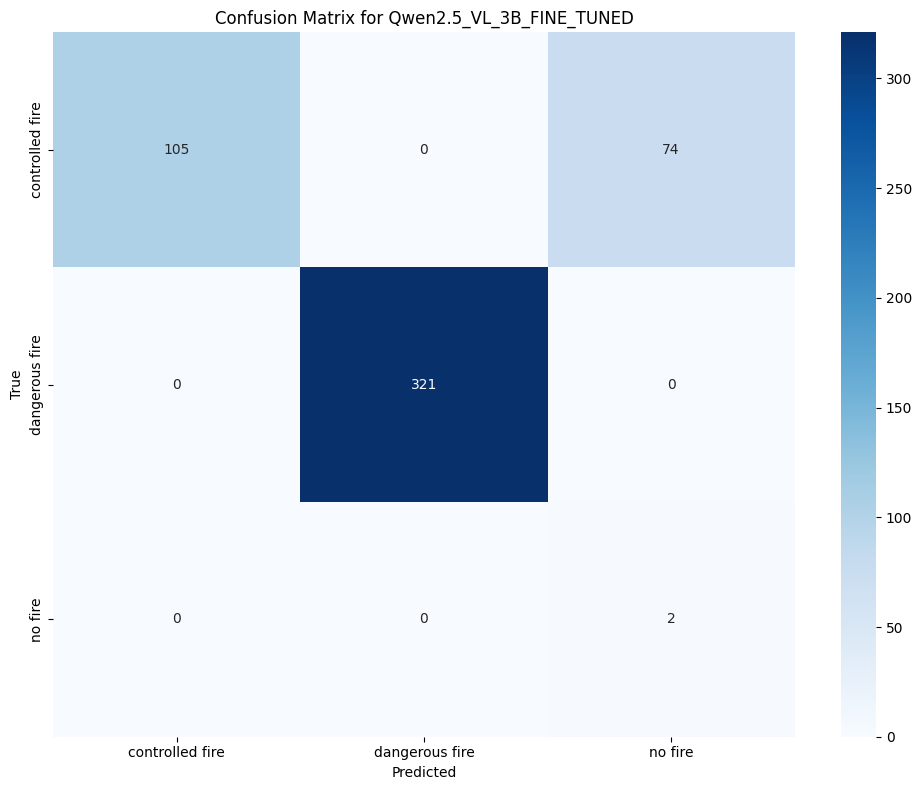

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion matrix
labels = sorted(df['true_label'].unique())
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Qwen2.5_VL_3B_FINE_TUNED')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()